In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
joebeachcapital_nsw_australia_electricity_demand_2018_2023_path = kagglehub.dataset_download('joebeachcapital/nsw-australia-electricity-demand-2018-2023')

print('Data source import complete.', joebeachcapital_nsw_australia_electricity_demand_2018_2023_path)

100%|██████████| 2.23M/2.23M [00:00<00:00, 13.0MB/s]

Extracting files...


Data source import complete. /root/.cache/kagglehub/datasets/joebeachcapital/nsw-australia-electricity-demand-2018-2023/versions/1


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
import holidays
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

import shap
shap.initjs()
sns.set_theme()

In [ ]:
path = "/root/.cache/kagglehub/datasets/joebeachcapital/nsw-australia-electricity-demand-2018-2023/versions/1"
all_files = glob.glob(os.path.join(path, "*.csv"))
df_raw = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
print("Raw rows:", len(df_raw))
df_raw

Raw rows: 248592


,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2018/06/01 00:30:00,8280.54,61.49,TRADE
1,NSW1,2018/06/01 01:00:00,8090.83,61.38,TRADE
2,NSW1,2018/06/01 01:30:00,7843.87,65.59,TRADE
3,NSW1,2018/06/01 02:00:00,7611.46,61.52,TRADE
4,NSW1,2018/06/01 02:30:00,7240.44,60.05,TRADE
...,...,...,...,...,...
248587,NSW1,2018/05/31 22:00:00,9380.76,69.29,TRADE
248588,NSW1,2018/05/31 22:30:00,9240.72,88.50,TRADE
248589,NSW1,2018/05/31 23:00:00,8899.83,68.51,TRADE
248590,NSW1,2018/05/31 23:30:00,8713.72,63.30,TRADE


In [ ]:
print(df_raw[df_raw.isnull().any(axis=1)])

Empty DataFrame
Columns: [REGION, SETTLEMENTDATE, TOTALDEMAND, RRP, PERIODTYPE]
Index: []


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248592 entries, 0 to 248591
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   REGION          248592 non-null  object 
 1   SETTLEMENTDATE  248592 non-null  object 
 2   TOTALDEMAND     248592 non-null  float64
 3   RRP             248592 non-null  float64
 4   PERIODTYPE      248592 non-null  object 
dtypes: float64(2), object(3)
memory usage: 9.5+ MB


In [ ]:
print(df_raw.isnull().sum()/len(df_raw))

REGION            0.0
SETTLEMENTDATE    0.0
TOTALDEMAND       0.0
RRP               0.0
PERIODTYPE        0.0
dtype: float64


In [ ]:
df_raw.describe()

,TOTALDEMAND,RRP
count,248592.000000,248592.000000
mean,7609.351612,128.619204
std,1270.924160,289.366592
min,3957.320000,-1000.000000
25%,6682.177500,59.950000
50%,7470.850000,89.010000
75%,8324.510000,144.410000
max,13700.900000,15500.000000


In [ ]:
print(df_raw['REGION'].value_counts())

REGION
NSW1    248592
Name: count, dtype: int64


In [ ]:
df_raw['SETTLEMENTDATE'].duplicated().sum()

np.int64(0)

In [ ]:
def build_features(df_raw):
    df = df_raw.copy()

    df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
    df = df.drop(columns=[c for c in ["REGION","PERIODTYPE"] if c in df.columns])
    df = df.sort_values("SETTLEMENTDATE").set_index("SETTLEMENTDATE")

    df = df.resample('30min').mean()


    try:
        nsw = holidays.Australia(state="NSW", years=range(df.index.year.min(), df.index.year.max() + 2))
        df["is_holiday"] = [1 if d in nsw else 0 for d in df.index.date]
    except Exception:
        df["is_holiday"] = (df.index.weekday >= 5).astype(int)


    df["hour"] = df.index.hour
    df["weekday"] = df.index.weekday
    df["month"] = df.index.month


    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)


    df["lag_1"] = df["TOTALDEMAND"].shift(1)
    df["lag_2"] = df["TOTALDEMAND"].shift(2)
    df["lag_48"] = df["TOTALDEMAND"].shift(48)
    df["lag_336"] = df["TOTALDEMAND"].shift(336)
    df["rolling_48"] = df["TOTALDEMAND"].shift(1).rolling(window=48).mean()
    df["rolling_336"] = df["TOTALDEMAND"].shift(1).rolling(window=336).mean()

    df["day_type"] = df.index.dayofweek.map({0:0, 1:0, 2:0, 3:0, 4:0, 5:1, 6:2})

    df["hour_day_interaction"] = df["hour"].astype(str) + "_" + df["day_type"].astype(str)
    df["hour_day_interaction"] = LabelEncoder().fit_transform(df["hour_day_interaction"])

    daily_fourier = CalendarFourier(freq="D", order=4)
    yearly_fourier = CalendarFourier(freq="A", order=2)

    dp = DeterministicProcess(
        index=df.index,
        constant=True,
        order=1,
        seasonal=False,
        period=48,
        additional_terms=[daily_fourier, yearly_fourier],
        drop=True
    )

    dp_feats = dp.in_sample().add_prefix("dp_")
    df = df.join(dp_feats)


    df = df.dropna()

    return df, dp

df, dp = build_features(df_raw)
print("Built rows:", len(df))
print(df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


Built rows: 95856
(95856, 32)


,TOTALDEMAND,RRP,is_holiday,hour,weekday,month,hour_sin,hour_cos,month_sin,month_cos,...,"dp_sin(2,freq=D)","dp_cos(2,freq=D)","dp_sin(3,freq=D)","dp_cos(3,freq=D)","dp_sin(4,freq=D)","dp_cos(4,freq=D)","dp_sin(1,freq=YE-DEC)","dp_cos(1,freq=YE-DEC)","dp_sin(2,freq=YE-DEC)","dp_cos(2,freq=YE-DEC)"
SETTLEMENTDATE,,,,,,,,,,,,,,,,,,,,,
2018-01-08 00:30:00,7641.48,75.58,0,0,0,1,0.000000,1.000000,0.0,1.0,...,0.258819,0.965926,0.382683,9.238795e-01,0.500000,8.660254e-01,0.120564,0.992706,0.239369,0.970929
2018-01-08 01:00:00,7367.35,75.68,0,1,0,1,0.258819,0.965926,0.0,1.0,...,0.500000,0.866025,0.707107,7.071068e-01,0.866025,5.000000e-01,0.120920,0.992662,0.240066,0.970757
2018-01-08 01:30:00,7000.75,56.93,0,1,0,1,0.258819,0.965926,0.0,1.0,...,0.707107,0.707107,0.923880,3.826834e-01,1.000000,6.123234e-17,0.121276,0.992619,0.240762,0.970584
2018-01-08 02:00:00,6796.19,54.78,0,2,0,1,0.500000,0.866025,0.0,1.0,...,0.866025,0.500000,1.000000,6.123234e-17,0.866025,-5.000000e-01,0.121632,0.992575,0.241458,0.970411
2018-01-08 02:30:00,6757.94,54.68,0,2,0,1,0.500000,0.866025,0.0,1.0,...,0.965926,0.258819,0.923880,-3.826834e-01,0.500000,-8.660254e-01,0.121988,0.992532,0.242154,0.970238


In [ ]:
FEATURE_LR = [c for c in df.columns if c.startswith("dp_")] + ["is_holiday"]

FEATURE_XGB = ["lag_1","lag_2","lag_48", "lag_336","rolling_48", "rolling_336","hour_sin","hour_cos","month_sin","month_cos","RRP","is_holiday", "hour_day_interaction"]

TARGET = "TOTALDEMAND"

n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.90)

train = df.iloc[:train_end]
valid = df.iloc[train_end:valid_end]
test  = df.iloc[valid_end:]

X1_train, y_train = train[FEATURE_LR], train[TARGET]
X1_valid, y_valid = valid[FEATURE_LR], valid[TARGET]
X1_test,  y_test  = test[FEATURE_LR],  test[TARGET]

X2_train = train[FEATURE_XGB]
X2_valid = valid[FEATURE_XGB]
X2_test  = test[FEATURE_XGB]

print("Shapes:", X1_train.shape, X1_valid.shape, X1_test.shape)

Shapes: (67099, 15) (19171, 15) (9586, 15)


In [ ]:
class BoostedHybrid:
    def __init__(self, model_1, model_2):
        self.model_1 = model_1
        self.model_2 = model_2
        self.fitted = False

    def fit(self, X1, X2, y, X1_valid=None, X2_valid=None, y_valid=None, xgb_params=None):
        self.model_1.fit(X1, y)
        y1_train = pd.Series(self.model_1.predict(X1), index=X1.index)
        resid_train = y - y1_train

        y1_valid = pd.Series(self.model_1.predict(X1_valid), index=X1_valid.index)
        resid_valid = y_valid - y1_valid
        self.model_2.fit(
            X2, resid_train,
            eval_set=[(X2_valid, resid_valid)]
        )


        self.y1_train = y1_train
        self.resid_train = resid_train
        self.fitted = True
        return self

    def predict(self, X1, X2, beta=1.0):
        y1 = pd.Series(self.model_1.predict(X1), index=X1.index)
        y2 = pd.Series(self.model_2.predict(X2), index=X2.index)
        return y1 + beta * y2

In [ ]:
# lr = LinearRegression()
# xgb = XGBRegressor(
#     n_estimators=3000,
#     learning_rate=0.015,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="reg:squarederror",
#     verbosity=0,
#     random_state=42
# )

rr = Ridge(alpha=0.35, fit_intercept=False)

lgb = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=50,
    reg_alpha=5.0,
    reg_lambda=10.0,
    metric="rmse",
    random_state=42,
    verbosity=-1,
)

model = BoostedHybrid(rr, lgb)
model.fit(X1_train, X2_train, y_train, X1_valid=X1_valid, X2_valid=X2_valid, y_valid=y_valid)
print("Fitted")


Fitted


In [ ]:
# Cell 6: evaluation helpers
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"RMSE":rmse, "MAE":mae, "R2":r2}

y_pred_train = model.predict(X1_train, X2_train)
y_pred_valid = model.predict(X1_valid, X2_valid)
y_pred_test  = model.predict(X1_test,  X2_test)

print("Train:", metrics(y_train, y_pred_train))
print("Valid:", metrics(y_valid, y_pred_valid))
print("Test: ", metrics(y_test,  y_pred_test))

Train: {'RMSE': np.float64(156.269830833012), 'MAE': 121.69766342100107, 'R2': 0.9843927423849922}
Valid: {'RMSE': np.float64(336.0190554537709), 'MAE': 275.2808306148113, 'R2': 0.9303218911932554}
Test:  {'RMSE': np.float64(483.9018181368745), 'MAE': 425.4878032760952, 'R2': 0.8523786437048182}


,Actual,Predicted
SETTLEMENTDATE,,
2022-12-10 07:30:00,6235.831667,6216.244307
2022-12-10 08:00:00,6053.511667,6020.523373
2022-12-10 08:30:00,5913.445000,5891.505106
2022-12-10 09:00:00,5948.463333,5794.406587
2022-12-10 09:30:00,5895.945000,5581.033674
...,...,...
2022-12-17 05:00:00,6217.876667,5787.874119
2022-12-17 05:30:00,6262.648333,5943.149320
2022-12-17 06:00:00,6366.251667,5557.637709


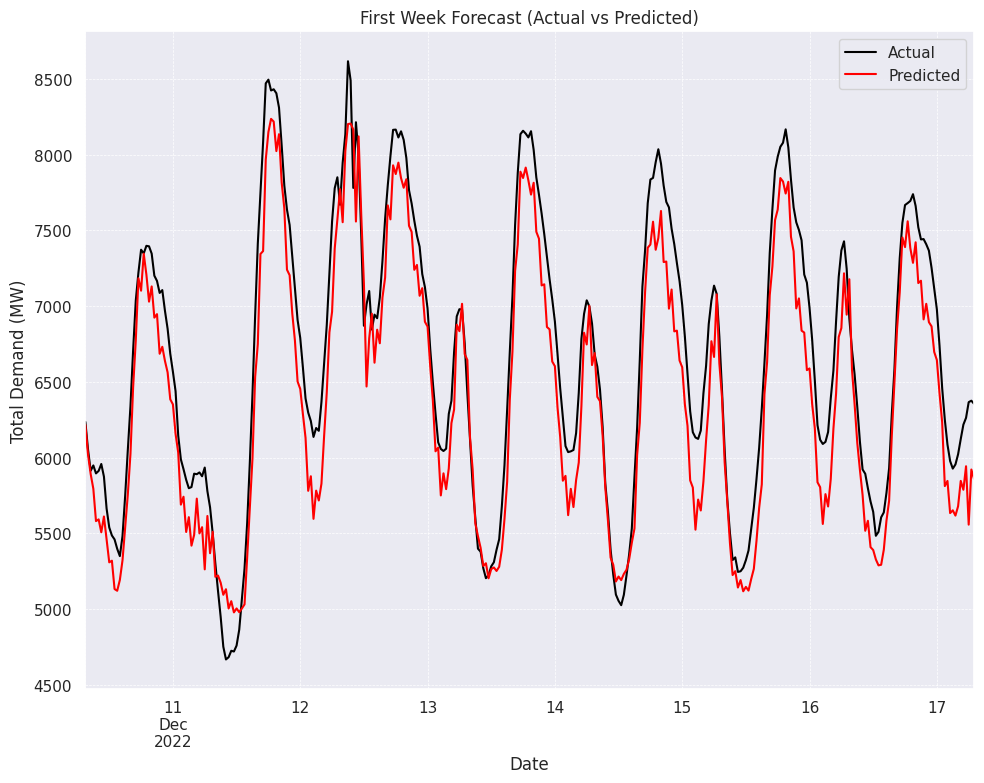

In [ ]:
results = pd.DataFrame(index=y_test.index)
results["Actual"] = y_test
results["Predicted"] = y_pred_test

display(results.iloc[:336])

results.iloc[:336].plot(
    y=["Actual", "Predicted"],
    figsize=(10, 8),
    title="First Week Forecast (Actual vs Predicted)",
    color=["black", "red"],
)

plt.ylabel("Total Demand (MW)")
plt.xlabel("Date")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# betas = [0.0, 0.25, 0.5, 0.7, 1.0]
# best, best_rmse = None, 1e18
# for a in betas:
#     yval_pred = model.predict(X1_valid, X2_valid, beta=a)
#     rmse = np.sqrt(mean_squared_error(y_valid, yval_pred))
#     print(a, "->", rmse)
#     if rmse < best_rmse:
#         best_rmse, best = rmse, a

# print("best beta:", best, "rmse:", best_rmse)

In [ ]:
X_sample = X2_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model.model_2)
shap_values = explainer.shap_values(X_sample)

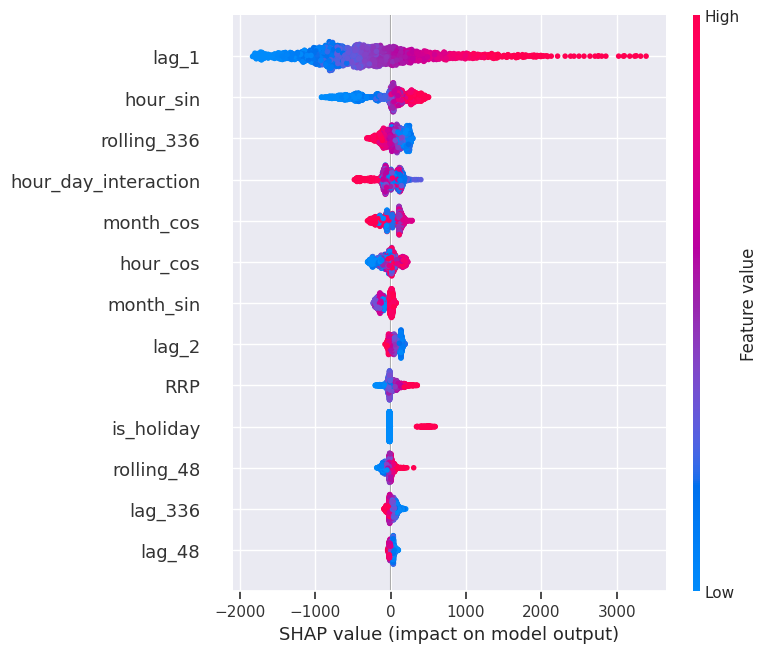

In [ ]:
shap.summary_plot(shap_values, X_sample, plot_type="dot")

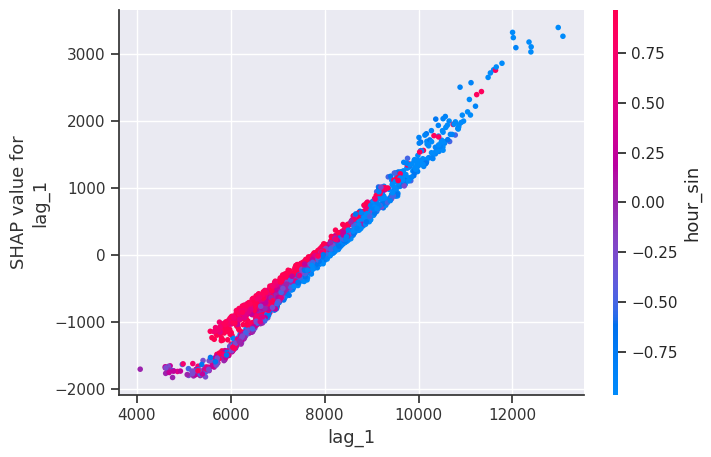

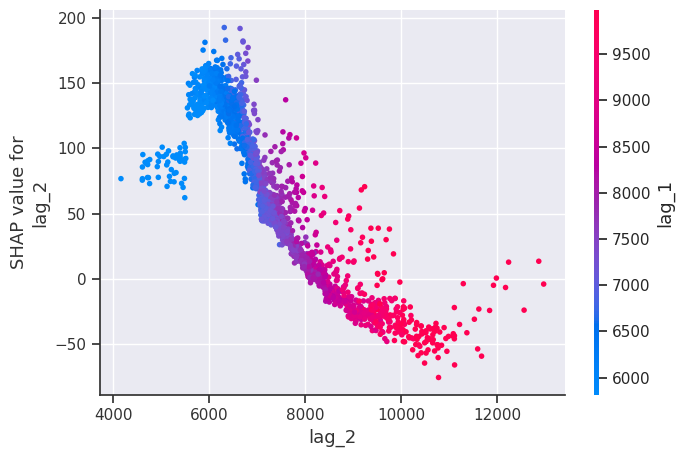

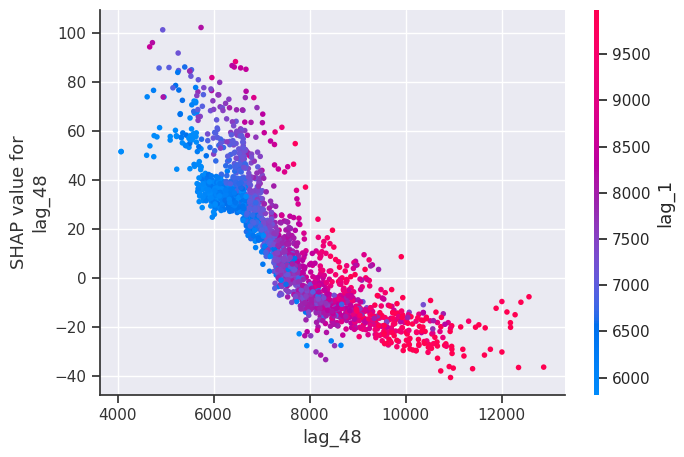

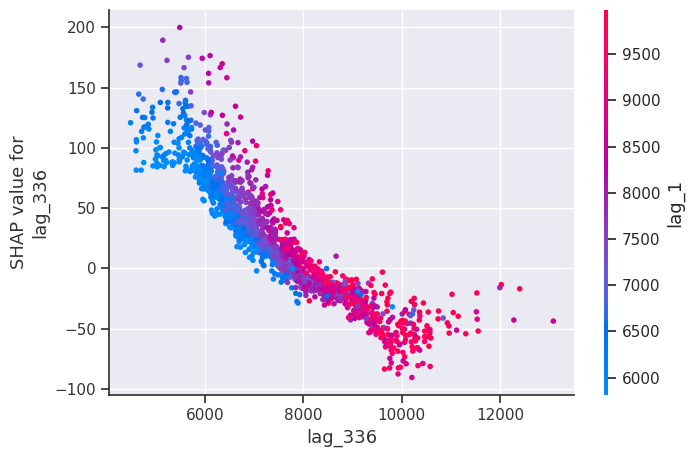

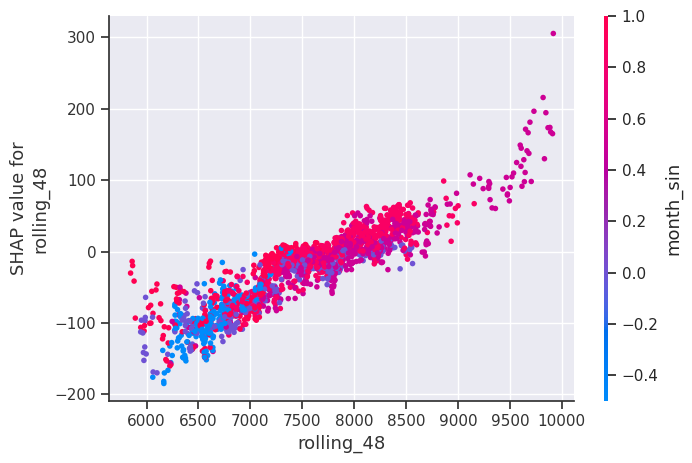

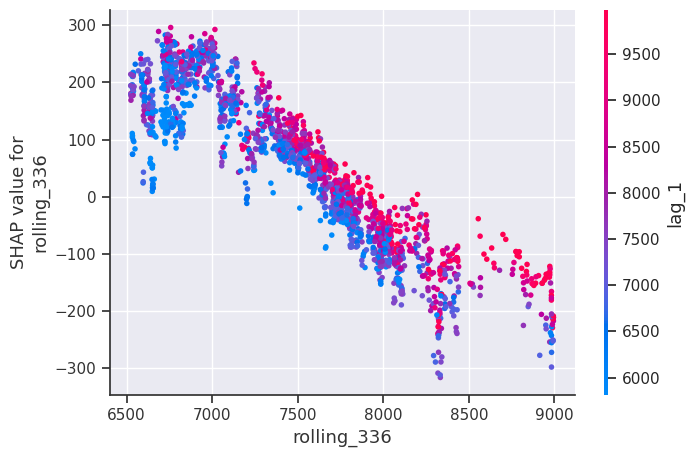

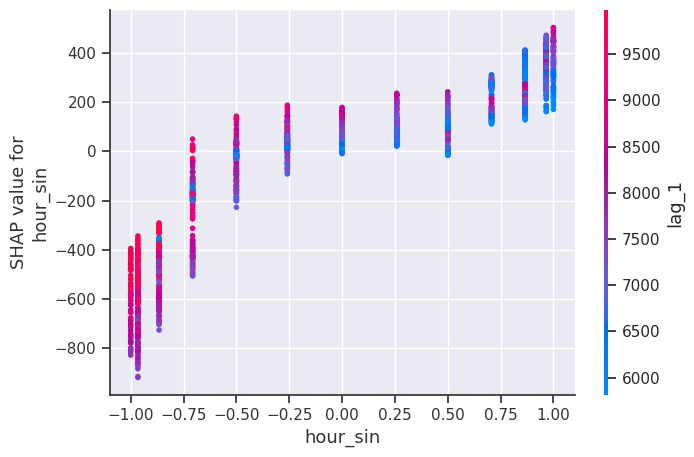

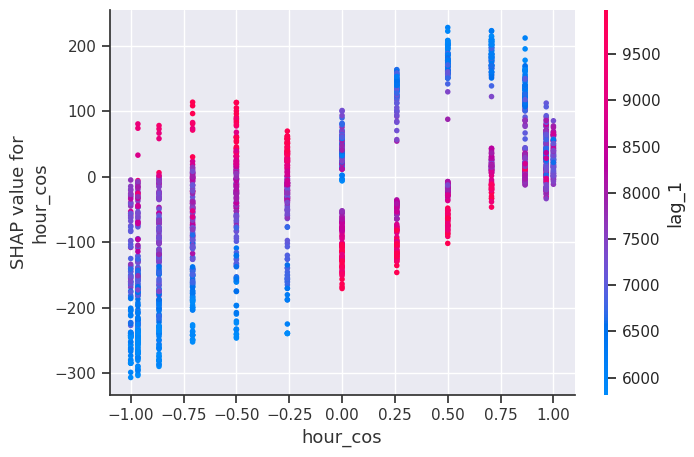

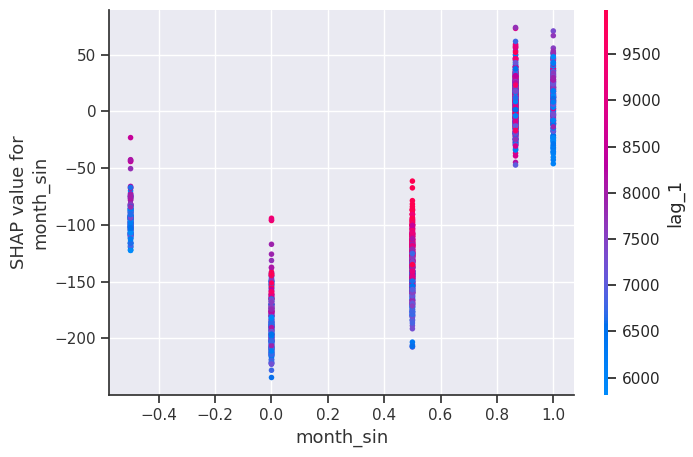

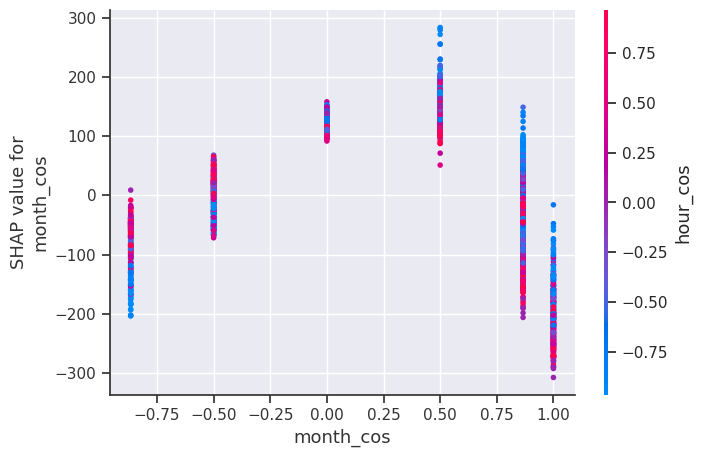

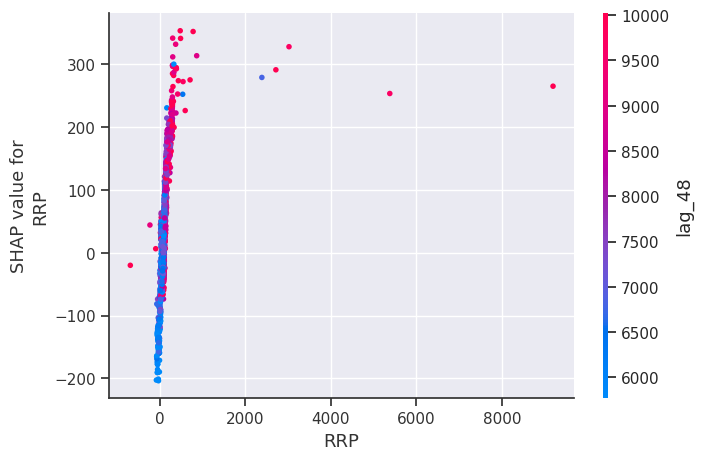

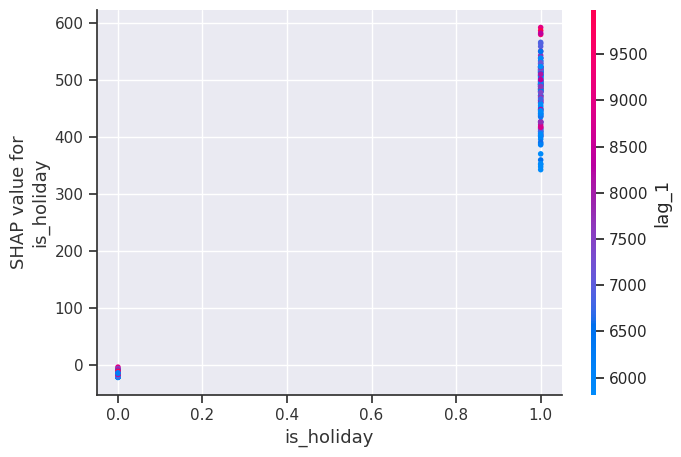

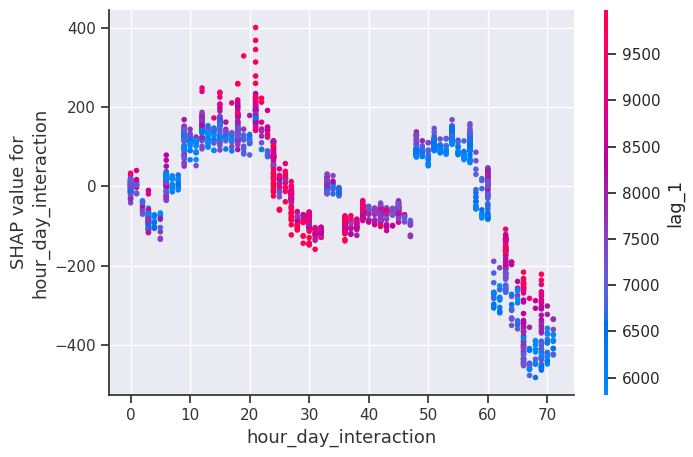

In [ ]:
for feat in FEATURE_XGB:
    shap.dependence_plot(feat, shap_values, X_sample)